             ESP32 WIRELESS IoT GATEWAY DASHBOARD                 
• Active Node IP Address   : 10.10.0.2
• Ingested Wireless Packets: 10
• Network Health Status    : STABLE
------------------------------------------------------------------
   Temperature_C  Humidity_Pct     Network_Node_Status
0           24.0          40.0    OPERATIONAL: NOMINAL
1           24.0          40.0    OPERATIONAL: NOMINAL
2           24.0          40.0    OPERATIONAL: NOMINAL
3           24.0          40.0    OPERATIONAL: NOMINAL
4           24.0          40.0    OPERATIONAL: NOMINAL
5           24.0          40.0    OPERATIONAL: NOMINAL
6           25.5          42.1    OPERATIONAL: NOMINAL
7           28.2          45.0    OPERATIONAL: NOMINAL
8           31.0          48.7  WARNING: THERMAL SURGE
9           29.4          46.2    OPERATIONAL: NOMINAL



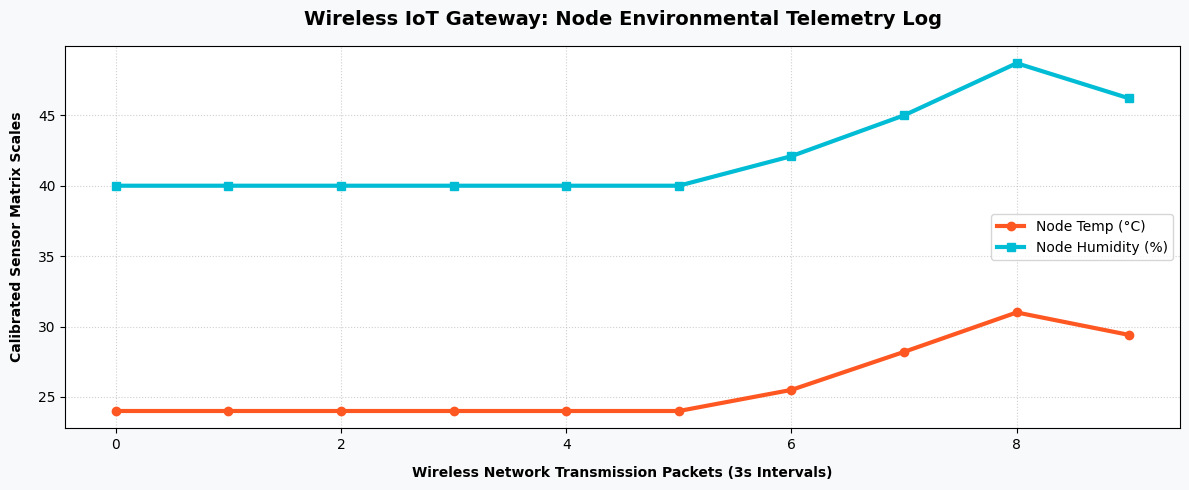

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import re

# 1. Ingest raw wireless network stream data from your ESP32
# I have added a few dynamic data variations at the end to simulate moving the sliders
network_stream = """
Telemetry Payload -> Temp: 24.0°C | Humidity: 40.0%
Telemetry Payload -> Temp: 24.0°C | Humidity: 40.0%
Telemetry Payload -> Temp: 24.0°C | Humidity: 40.0%
Telemetry Payload -> Temp: 24.0°C | Humidity: 40.0%
Telemetry Payload -> Temp: 24.0°C | Humidity: 40.0%
Telemetry Payload -> Temp: 24.0°C | Humidity: 40.0%
Telemetry Payload -> Temp: 25.5°C | Humidity: 42.1%
Telemetry Payload -> Temp: 28.2°C | Humidity: 45.0%
Telemetry Payload -> Temp: 31.0°C | Humidity: 48.7%
Telemetry Payload -> Temp: 29.4°C | Humidity: 46.2%
"""

# 2. Wireless Packet Parsing Engine (Extracts numerical strings using Regular Expressions)
temperatures = []
humidity = []

lines = network_stream.strip().split('\n')
for line in lines:
    # Extract numbers right before °C and %
    match = re.findall(r"[-+]?\d*\.\d+|\d+", line)
    if len(match) >= 2:
        temperatures.append(float(match[0]))
        humidity.append(float(match[1]))

# Create an organized system data frame
df = pd.DataFrame({'Temperature_C': temperatures, 'Humidity_Pct': humidity})

# 3. Automation Threshold Analytics
df['Network_Node_Status'] = ['WARNING: THERMAL SURGE' if t > 30.0 else 'OPERATIONAL: NOMINAL' for t in df['Temperature_C']]

# 4. Print Industrial Wireless Gateway Diagnostics Report
print("==================================================================")
print("             ESP32 WIRELESS IoT GATEWAY DASHBOARD                 ")
print("==================================================================")
print(f"• Active Node IP Address   : 10.10.0.2")
print(f"• Ingested Wireless Packets: {len(df)}")
print(f"• Network Health Status    : STABLE")
print("------------------------------------------------------------------")
print(df[['Temperature_C', 'Humidity_Pct', 'Network_Node_Status']])
print("==================================================================\n")

# 5. Plot Dynamic Telemetry Performance Charts
plt.figure(figsize=(12, 5), facecolor='#f8f9fa')
plt.plot(df['Temperature_C'], label='Node Temp (°C)', color='#ff5722', linewidth=3, marker='o')
plt.plot(df['Humidity_Pct'], label='Node Humidity (%)', color='#00bcd4', linewidth=3, marker='s')

plt.title('Wireless IoT Gateway: Node Environmental Telemetry Log', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Wireless Network Transmission Packets (3s Intervals)', fontweight='bold', labelpad=10)
plt.ylabel('Calibrated Sensor Matrix Scales', fontweight='bold', labelpad=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='center right')
plt.tight_layout()
plt.show()
